# Smart Crop Recommendation System
### Team H — Decision Tree Assignment

## 1. Problem Statement

Predict the most suitable crop to grow based on **soil type**, **rainfall level**, and **season**, helping farmers make data-driven planting decisions.

## 2. Input Features

| Feature | Possible Values |
|---|---|
| Soil Type | Clayey, Sandy, Loamy |
| Rainfall | Low, Medium, High |
| Season | Summer, Winter, Monsoon |

## 3. Output Class (Target)

**Recommended Crop** — e.g. Rice, Wheat, Sugarcane, Millet, Groundnut, Maize, Cotton, Barley

## 4. Decision Tree Representation

```text
                        [Soil Type]
                       /     |      \
                 Clayey   Sandy    Loamy
                    |        |         |
              [Rainfall]  [Season]  [Rainfall]
               /    \      /   \      /    \
            High    Low  Sum  Win   High   Low
             |       |    |    |     |      |
           Rice   Wheat Millet Wheat Maize Cotton
```

**Example decision logic:**
- Clayey soil + High rainfall → **Rice**
- Clayey soil + Low rainfall → **Wheat**
- Sandy soil + Summer → **Millet**
- Sandy soil + Winter → **Wheat**
- Loamy soil + High rainfall → **Maize**
- Loamy soil + Low rainfall → **Cotton**


## 5. Identify the Components

| Component | In This Tree |
|---|---|
| **Root Node** | Soil Type |
| **Internal Nodes** | Rainfall, Season |
| **Branches** | Edges labeled with values like "Clayey", "High", "Winter", etc. |
| **Leaf Nodes** | Final crop outputs — Rice, Wheat, Millet, Maize, Cotton, etc. |

## 6. Why Soil Type is the Appropriate Root Node

- **Most influential factor**: Soil type determines water retention, nutrient availability, and drainage.
- **Highest information gain**: Soil type reduces uncertainty more than rainfall or season.
- **Stability**: Soil type remains constant while rainfall and season vary.
- **Practical logic**: Farmers evaluate soil first, then rainfall and season.

## 7. Python Code — Decision Tree Implementation

Steps: **Load Data → Split → Train → Predict → Accuracy**

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
# 1. Load Data
df = pd.read_csv("C:\clg files\ITA06_MACHINE_LEARNING_FILES\ALL_DATASETS\crop_dataset-1.csv")


In [4]:
# Encode categorical (text) columns into numbers
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df[["Soil_Type", "Rainfall", "Season"]]
y = df["Recommended_Crop"]

In [5]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# 3. Train Model
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [7]:
# 4. Predict
y_pred = model.predict(X_test)

In [8]:
# 5. Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


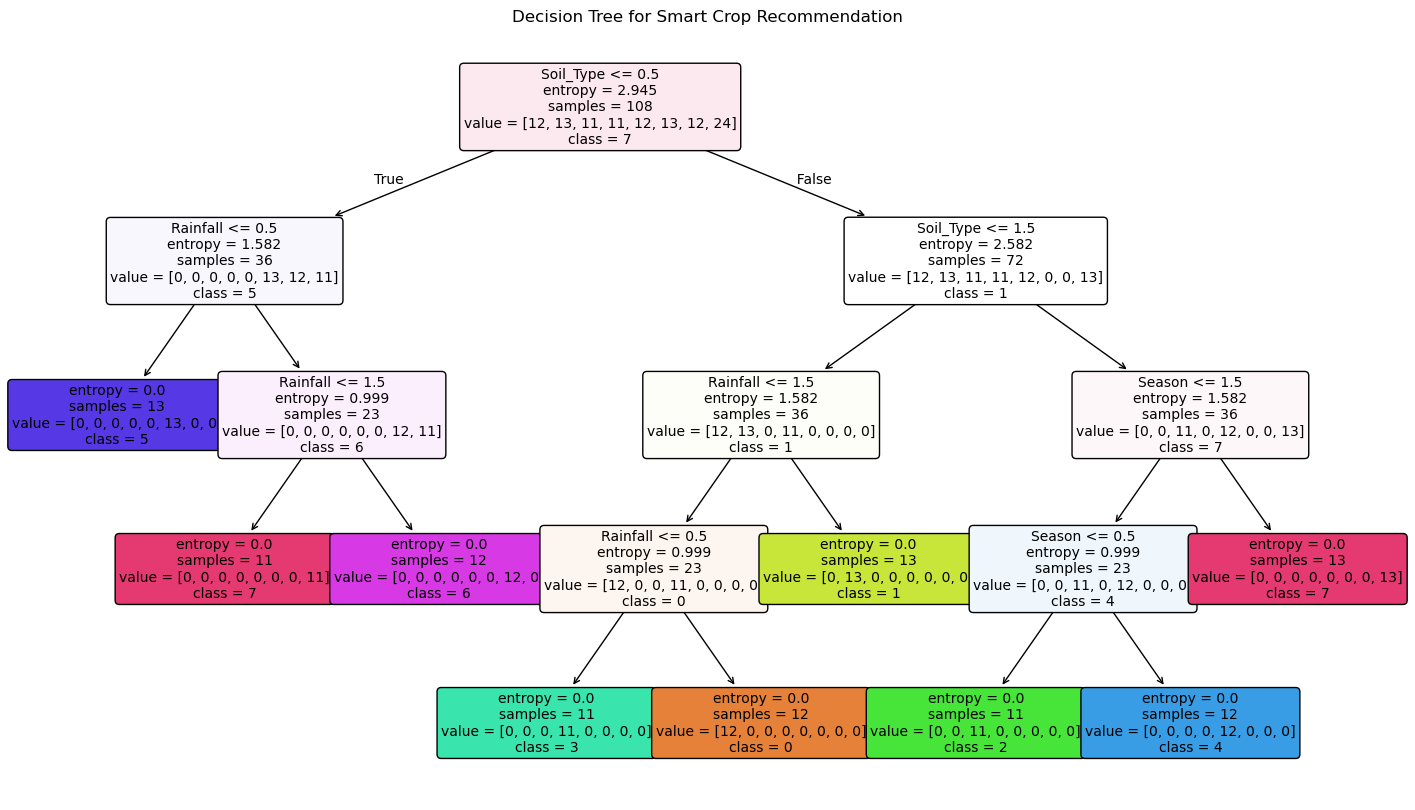

In [9]:
# 6. Display Decision Tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(i) for i in model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Smart Crop Recommendation")
plt.show()